# Hyperparameter Tuning of 1D conv net

In [2]:
%load_ext autoreload
%autoreload 2

In [18]:
from src.config import set_seeds, get_complete_path, MODELS_DIR, SAFE_VAR_NAME
import src.pipeline as pipe
import src.models as mod
import src.models.nn as nn
import src.evaluation as eval
import src.visualization as visual
import src.reporting as rep
import pandas as pd
import tensorflow as tf
import numpy as np
import os
import gc
import optuna
import pickle
from tensorflow.keras.callbacks import ModelCheckpoint # type: ignore
from optuna_integration.tfkeras import TFKerasPruningCallback
from optuna.samplers import RandomSampler, TPESampler

In [4]:
set_seeds()

In [27]:
INDICATORS = ['Livestock production index (2014-2016 = 100)']

DF_CATEGORIES = ['orig', 'step_aug', 'jitter_aug']

# 'Fertilizer consumption (% of fertilizer production)'

In [28]:
df = pipe.load_data()
display(df.head())

Dataset caricato: 65 anni, 28 variabili.


,Year,Agricultural land (% of land area),Agricultural land (sq. km),Agricultural raw materials exports (% of merchandise exports),Agricultural raw materials imports (% of merchandise imports),"Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (current US$)","Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)",Arable land (% of land area),Arable land (hectares per person),...,Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land under cereal production (hectares),Livestock production index (2014-2016 = 100),Permanent cropland (% of land area),Rural population,Rural population (% of total population),Rural population growth (annual %)
0,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20400656.0,40.639,NaN
1,1961,70.324028,206830.0,NaN,NaN,NaN,NaN,NaN,43.731937,0.254510,...,67.795055,85.93,NaN,NaN,6387203.0,70.91,9.336643,20287312.0,40.144,-0.557139
2,1962,70.218626,206520.0,2.563660,16.566057,NaN,NaN,NaN,43.504131,0.251477,...,69.362485,86.90,NaN,NaN,6485855.0,72.59,9.435245,20171158.0,39.645,-0.574190
3,1963,69.735813,205100.0,2.651714,14.571604,NaN,NaN,NaN,43.092720,0.247288,...,68.764636,86.37,NaN,NaN,6299467.0,65.95,9.319642,20063620.0,39.147,-0.534554
4,1964,69.572609,204620.0,2.792923,15.115329,NaN,NaN,NaN,42.834314,0.243791,...,74.639625,90.28,NaN,NaN,6244904.0,69.57,9.438645,19972523.0,38.650,-0.455075


============================== LIVESTOCK PRODUCTION INDEX (2014-2016 = 100) ==============================
Train: 1961-2003 (43 obs)
Val:   2004-2013 (10 obs)
Test:  2014-2022 (9 obs)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\AUGMENTATION\AUG_livestock_production_index.png


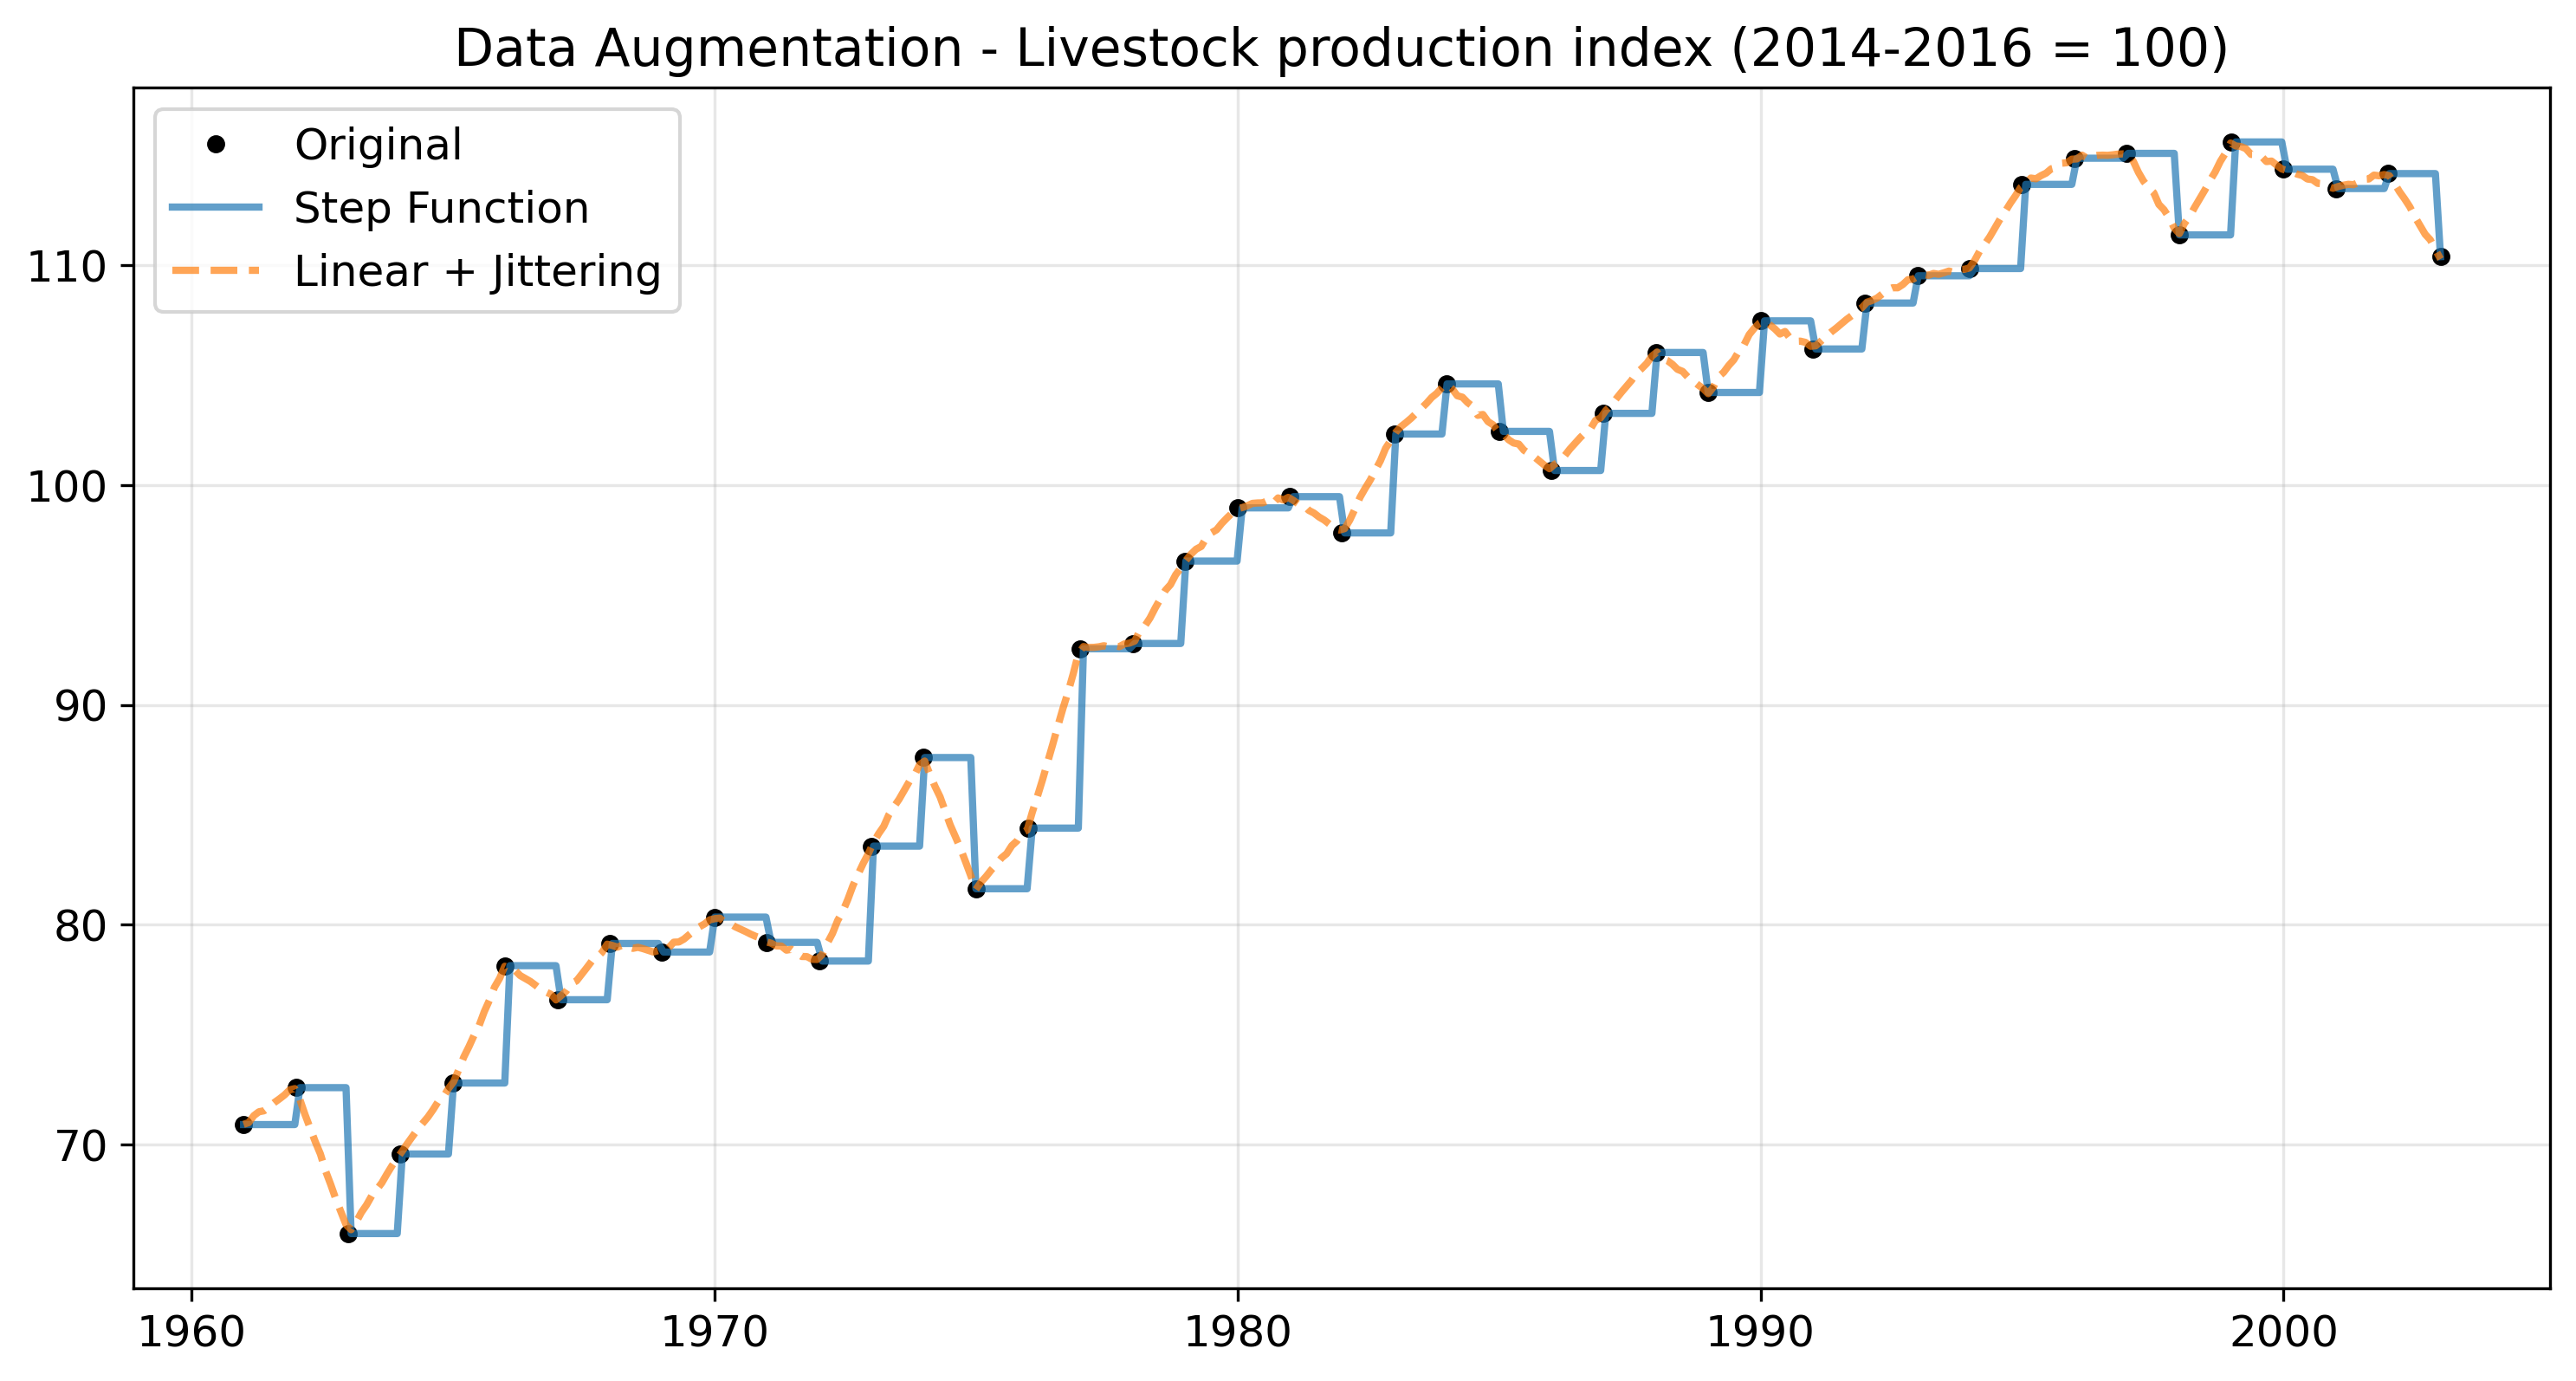

In [29]:
orig_aug_subsets = {}

for indicator in INDICATORS:
    print('='*30, indicator.upper(), '='*30)
    df_temp = df[['Year', indicator]].dropna().copy()
    df_temp.columns = ['Year', 'Value']
    train_orig, val_orig, test_orig = pipe.split_train_val_test(df_temp)    # splitto la time serie ORIGINALE
    
    x_train_vals = train_orig['Year']
    y_train_vals = train_orig['Value']
    
    df_step = pipe.augment_step_function(x_train_vals, y_train_vals, scale_factor=10)
    df_jitter = pipe.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
    visual.plot_augmented(indicator, df_step, df_jitter, x_train_vals, y_train_vals)
    orig_aug_subsets[indicator] = {
        'full_orig': df_temp,
        'orig_train': train_orig,
        'step_aug_train': df_step,
        'jitter_aug_train': df_jitter,
        'orig_val': val_orig,
        'orig_test': test_orig
    }

In [30]:
scaled_orig_aug_subsets = {} 
scalers_subsets = {}
for indicator in INDICATORS:
    scaled_subsets, scalers = pipe.scale_datasets(orig_aug_subsets[indicator])
    scaled_orig_aug_subsets[indicator] = scaled_subsets
    scalers_subsets[indicator] = scalers

In [31]:
scaled_table_subsets = {}
for indicator in INDICATORS:
    window_size = 3
    table_train_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_train'], window_size, step=1)
    table_train_step = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['step_aug_train'], window_size, step=1)
    table_train_jitter = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['jitter_aug_train'], window_size, step=1)
    table_val_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_val'], window_size, step=1)
    table_test_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_test'], window_size, step=1)
    scaled_table_subsets[indicator] = {
        'train_orig' : table_train_orig,
        'train_step' : table_train_step,
        'train_jitter' : table_train_jitter,
        'val_orig' : table_val_orig,
        'test_orig' : table_test_orig
    }

In [32]:
final_table_train_sets = {}
final_table_val_test_sets = {}

for indicator in INDICATORS:
    # X: filtra colonne ts_*
    # y: prende colonna 'target'
    X_train_orig_to_reshape = scaled_table_subsets[indicator]['train_orig'].filter(regex=r'^ts_').copy()
    y_train_orig_to_reshape = scaled_table_subsets[indicator]['train_orig']['target'].copy()
    
    X_train_step_to_reshape = scaled_table_subsets[indicator]['train_step'].filter(regex=r'^ts_').copy()
    y_train_step_to_reshape = scaled_table_subsets[indicator]['train_step']['target'].copy()
    
    X_train_jitter_to_reshape = scaled_table_subsets[indicator]['train_jitter'].filter(regex=r'^ts_').copy()
    y_train_jitter_to_reshape = scaled_table_subsets[indicator]['train_jitter']['target'].copy()
    
    X_val_orig_to_reshape = scaled_table_subsets[indicator]['val_orig'].filter(regex=r'^ts_').copy()
    y_val_orig_to_reshape = scaled_table_subsets[indicator]['val_orig']['target'].copy()
    
    X_test_orig_to_reshape = scaled_table_subsets[indicator]['test_orig'].filter(regex=r'^ts_').copy()
    y_test_orig_to_reshape = scaled_table_subsets[indicator]['test_orig']['target'].copy()
    
    # Reshape X: (samples, window_size, 1)
    X_train_orig = X_train_orig_to_reshape.values.reshape((X_train_orig_to_reshape.shape[0], X_train_orig_to_reshape.shape[1], 1))
    X_train_step = X_train_step_to_reshape.values.reshape((X_train_step_to_reshape.shape[0], X_train_step_to_reshape.shape[1], 1))
    X_train_jitter = X_train_jitter_to_reshape.values.reshape((X_train_jitter_to_reshape.shape[0], X_train_jitter_to_reshape.shape[1], 1))
    X_val_orig = X_val_orig_to_reshape.values.reshape((X_val_orig_to_reshape.shape[0], X_val_orig_to_reshape.shape[1], 1))
    X_test_orig = X_test_orig_to_reshape.values.reshape((X_test_orig_to_reshape.shape[0], X_test_orig_to_reshape.shape[1], 1))
    
    # Reshape y: (samples, 1)
    y_train_orig = y_train_orig_to_reshape.values.reshape(-1, 1)
    y_train_step = y_train_step_to_reshape.values.reshape(-1, 1)
    y_train_jitter = y_train_jitter_to_reshape.values.reshape(-1, 1)
    y_val_orig = y_val_orig_to_reshape.values.reshape(-1, 1)
    y_test_orig = y_test_orig_to_reshape.values.reshape(-1, 1)
    
    final_table_train_sets[indicator] = {
        'train_orig' : (X_train_orig, y_train_orig),
        'train_step' : (X_train_step, y_train_step),
        'train_jitter' : (X_train_jitter, y_train_jitter),
    }
    
    final_table_val_test_sets[indicator] = {
        'val_orig': (X_val_orig, y_val_orig),
        'test_orig' : (X_test_orig, y_test_orig)
    }
    
    print("train orig", X_train_orig[0], y_train_orig[0])
    print("step", X_train_step[0], y_train_step[0])
    print("jitter", X_train_jitter[0], y_train_jitter[0])
    print("val", X_val_orig[0], y_val_orig[0])
    print("test", X_test_orig[0], y_test_orig[0])

train orig [[0.09985907]
 [0.1336823 ]
 [0.        ]] [0.07288101]
step [[0.09985907]
 [0.09985907]
 [0.09985907]] [0.09985907]
jitter [[0.10006334]
 [0.10164462]
 [0.10803959]] [0.11160098]
val [[0.89249044]
 [0.88141735]
 [0.82987719]] [0.8999396]
test [[0.60539561]
 [0.71592511]
 [0.73525267]] [0.68733642]


### 1. Iperparametri Architetturali (Specifici CNN)
- **Number of Filters**: [16, 32, 64, 128]. Più filtri = più capacità di vedere dettagli, ma più rischio overfitting.
- **Kernel Size**: [3, 5, 7].
    - Piccolo (3): Vede dettagli fini/rumore ad alta frequenza.
    - Grande (7): Vede trend più ampi/lisciati.
- **Pooling Type**: [MaxPooling, AveragePooling, None]. A volte con soli 60 punti, non fare pooling è meglio (o usare "Global Average Pooling" alla fine).
- **Number of Conv Blocks**: [1, 2].
<br>
Attenzione: Se metti 3 layer di pooling (diviso 2 tre volte), 60 diventa 7.5 -> 7 punti. Con 4 layer arrivi a 3 punti. Optuna deve sapere di non esagerare con la profondità su serie corte.

### 2. Iperparametri Strutturali (Simili all'MLP)
- **Dense Layer Size**: quanti neuroni nel layer dopo il Flatten.
- **Dropout Rate**: [0.2 - 0.5] dopo la convoluzione o dopo il dense layer.

### 3. Iperparametri di Training (Identici all'MLP)
- **Learning Rate**.
- **Batch Size**.
- **Optimizer** (Adam, RMSprop, ecc.).

Per una CNN, spesso servono finestre più ampie rispetto a un MLP per catturare pattern

In [33]:
def objective(trial, scaled_data_dict):
    n_input_steps = trial.suggest_int('n_input_steps', 6, 24) 
    
    # Search Space
    params = {
        # Struttura Convoluzionale
        'n_conv_layers': trial.suggest_int('n_conv_layers', 1, 2),      # Numero di blocchi Conv
        'filters': trial.suggest_categorical('filters', [16, 32, 64]),
        'kernel_size': trial.suggest_int('kernel_size', 2, 5),          # Quanto è grande la "lente" della conv
        'pool_size': 2,                                                 # volendo posso tunarlo (es. suggest_int(2,3))
        
        # Struttura Dense (Head della rete)
        'dense_units': trial.suggest_int('dense_units', 16, 64),
        'activation': 'relu', # Relu è standard per CNN, ma posso usare trial.suggest nel caso
        
        # Training
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32]),
        'dropout': trial.suggest_float('dropout', 0.1, 0.4),
        'input_shape': (n_input_steps, 1)
    }
    
    # Check di sicurezza: il kernel non può essere più grande dell'input
    if params['kernel_size'] >= n_input_steps:
        raise optuna.TrialPruned()

    train_data = scaled_data_dict['train']
    val_data = scaled_data_dict['val']
    
    X_train, y_train = pipe.create_sequences(train_data['Value'], n_input_steps)
    X_val, y_val = pipe.create_sequences(val_data['Value'], n_input_steps)
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
    
    if len(X_train) == 0 or len(X_val) == 0:
        raise optuna.TrialPruned()

    model = nn.build_cnn_model(params) 
    
    pruning_callback = TFKerasPruningCallback(trial, "val_loss")
    
    history, model = nn.train_model(    
        model, 
        X_train, y_train, 
        X_val, y_val,
        batch_size=params['batch_size'],
        epochs=50, 
        patience=10,
        extra_callbacks=[pruning_callback]
    )
    
    if 'val_loss' not in history.history:
        return float('inf')
        
    best_val_loss = min(history.history['val_loss'])
    return best_val_loss

In [34]:
tuning_results = []
BACKUP_FILE = "tuning_results_cnn_backup.pkl"
N_TRIALS = 20

# Definisco il Pruner una volta fuori (Hyperband è ottimo per Deep Learning)
# resource: numero di epoche
pruner = optuna.pruners.HyperbandPruner(min_resource=5, max_resource=50, reduction_factor=3)

for SAMPLER_MODE in ["Random", "TPE"]:
    for indicator in INDICATORS:
        print(f"\n{'='*40} PROCESSING: {indicator} [{SAMPLER_MODE}] {'='*40}")
        
        for df_category in DF_CATEGORIES:
            print(f"\n Optimizing: {df_category}")
            
            if SAMPLER_MODE == "Random":
                sampler = RandomSampler(seed=42)
            else:
                sampler = TPESampler(seed=42, n_startup_trials=10) 
        
            try:
                data_package = {
                    'train': scaled_orig_aug_subsets[indicator][f'{df_category}_train'],
                    'val': scaled_orig_aug_subsets[indicator]['orig_val']
                }
            except KeyError as e:
                print(f"Data Error: dataset {e} missing for {indicator}. Skipping.")
                continue
            
            safe_var = SAFE_VAR_NAME.get(indicator, indicator[:3])
            safe_var = "".join([c if c.isalnum() else "_" for c in safe_var])[:50]
            
            study_name = f"CNN_{indicator}_{df_category}_{SAMPLER_MODE}"
            study = optuna.create_study(
                direction='minimize', 
                sampler=sampler, 
                pruner=pruner,
                study_name=study_name
            )
            
            try:
                study.optimize(
                    lambda trial: objective(trial, data_package), 
                    n_trials=N_TRIALS,
                    gc_after_trial=True # Pulisce la memoria dopo ogni trial
                )
            except Exception as e:
                print(f"Optuna crash on {indicator} - {df_category}: {e}")
                continue

            result_entry = {
                "indicator": indicator,
                "sampler": SAMPLER_MODE,
                "dataset_type": df_category,
                "best_params": study.best_params,
                "best_val_loss": study.best_value,
                "n_trials": N_TRIALS,
                "model_type": "CNN"
            }
            
            tuning_results.append(result_entry)
            print(f"Saved params for {indicator} ({df_category}) -> Loss: {study.best_value:.5f}")

            with open(BACKUP_FILE, "wb") as f:
                pickle.dump(tuning_results, f)
            
            tf.keras.backend.clear_session()
            gc.collect()

print(f"\n trovati i parametri ottimali per {len(tuning_results)} configurazioni.")

[I 2025-12-12 16:50:19,019] A new study created in memory with name: CNN_Livestock production index (2014-2016 = 100)_orig_Random
[W 2025-12-12 16:50:19,025] Trial 0 failed with parameters: {'n_input_steps': 13, 'n_conv_layers': 2, 'filters': 16, 'kernel_size': 2, 'dense_units': 18, 'learning_rate': 0.005399484409787433, 'batch_size': 32, 'dropout': 0.10617534828874074} because of the following error: IndexError('tuple index out of range').
Traceback (most recent call last):
  File "c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\oldan\AppData\Local\Temp\ipykernel_16596\2866566634.py", line 43, in <lambda>
    lambda trial: objective(trial, data_package),
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\oldan\AppData\Local\Temp\ipykernel_16596\2037732107.py", line 34, in objective
    X_val = X_val.re


======================================== PROCESSING: Livestock production index (2014-2016 = 100) [Random] ========================================

 Optimizing: orig
Optuna crash on Livestock production index (2014-2016 = 100) - orig: tuple index out of range

 Optimizing: step_aug


[I 2025-12-12 16:50:19,396] A new study created in memory with name: CNN_Livestock production index (2014-2016 = 100)_step_aug_Random
[W 2025-12-12 16:50:19,402] Trial 0 failed with parameters: {'n_input_steps': 13, 'n_conv_layers': 2, 'filters': 16, 'kernel_size': 2, 'dense_units': 18, 'learning_rate': 0.005399484409787433, 'batch_size': 32, 'dropout': 0.10617534828874074} because of the following error: IndexError('tuple index out of range').
Traceback (most recent call last):
  File "c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\oldan\AppData\Local\Temp\ipykernel_16596\2866566634.py", line 43, in <lambda>
    lambda trial: objective(trial, data_package),
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\oldan\AppData\Local\Temp\ipykernel_16596\2037732107.py", line 34, in objective
    X_val = X_va

Optuna crash on Livestock production index (2014-2016 = 100) - step_aug: tuple index out of range

 Optimizing: jitter_aug
Optuna crash on Livestock production index (2014-2016 = 100) - jitter_aug: tuple index out of range

======================================== PROCESSING: Livestock production index (2014-2016 = 100) [TPE] ========================================

 Optimizing: orig


[I 2025-12-12 16:50:19,878] A new study created in memory with name: CNN_Livestock production index (2014-2016 = 100)_orig_TPE
[W 2025-12-12 16:50:19,878] Trial 0 failed with parameters: {'n_input_steps': 13, 'n_conv_layers': 2, 'filters': 16, 'kernel_size': 2, 'dense_units': 18, 'learning_rate': 0.005399484409787433, 'batch_size': 32, 'dropout': 0.10617534828874074} because of the following error: IndexError('tuple index out of range').
Traceback (most recent call last):
  File "c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\oldan\AppData\Local\Temp\ipykernel_16596\2866566634.py", line 43, in <lambda>
    lambda trial: objective(trial, data_package),
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\oldan\AppData\Local\Temp\ipykernel_16596\2037732107.py", line 34, in objective
    X_val = X_val.resha

Optuna crash on Livestock production index (2014-2016 = 100) - orig: tuple index out of range

 Optimizing: step_aug
Optuna crash on Livestock production index (2014-2016 = 100) - step_aug: tuple index out of range

 Optimizing: jitter_aug
Optuna crash on Livestock production index (2014-2016 = 100) - jitter_aug: tuple index out of range

 trovati i parametri ottimali per 0 configurazioni.
